# E2a — 레이어별 K± / C± 프로브 AUROC (p8s-v2, 현경 산출물 기준)

E1a 산출물(`new_data/`)을 입력으로 쓴다. hidden은 재추출하지 않는다.

| 입력 | 내용 |
|---|---|
| `hidden/p8s_v2_h_out.npy` | 층 출력 hidden `(1224, 32, 4096)` fp16. **index 0 = layer 1 출력 (embedding 없음)** |
| `labels/p8s_behavior_v2.csv` | K± 라벨 3종 + `ctx_label` |

## K± 라벨 3종

closed-book 재판정에서 612문항 중 95건(15.5%)이 뒤집혔고, flip 79건(K+→K−)을 사람이
검토한 결과 절반만 실제 오답이었다. 나머지는 gold 목록 누락·별칭 문제였다.
그래서 K± 판정에만 완화 매칭을 적용한 라벨이 추가됐다. **EM 주지표는 그대로다.**

| 컬럼 | 정의 |
|---|---|
| `kside_new` | 엄격 EM. 채점 아티팩트 포함 |
| `kside_k` | 완화 매칭(부분포함 허용) |
| `kside_corr` | 완화 + audit 라벨 수동 보정 |

세 라벨을 모두 돌려 **곡선이 채점 방식에 얼마나 민감한지** 함께 보고한다.
C±(`ctx_label`)는 데이터 구성 시 정해진 값이라 재판정 대상이 아니며, 어느 조건에서도 동일해야 한다.

런타임: **CPU로 충분하다.**

## 0. 환경 + CONFIG

In [4]:
!pip -q install -U scikit-learn

import os, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from google.colab import drive
drive.mount('/content/drive')

# new_data 폴더 경로 (바로가기 추가한 위치로 수정)
ND = "/content/drive/MyDrive/new_data/"

CONFIG = {
    "HIDDEN":   ND + "hidden/p8s_v2_h_out.npy",
    "META":     ND + "hidden/p8s_v2_meta.json",
    "LABELS":   ND + "labels/p8s_behavior_v2.csv",
    "ORDER_CSV": "/content/drive/MyDrive/Grad_share/data_share/P9/p8s_behavior.csv",  # hidden 행 순서 기준
    "OUT_DIR":  "/content/drive/MyDrive/p8s/E2a_v2_final",
    "K_COLS":   ["kside_new", "kside_k", "kside_corr"],
    "N_SPLITS": 5,
    "LOGREG_C": 0.1,
    "GATE_LO": 8, "GATE_HI": 14, "GATE_THR": 0.65,
}
os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)
for k in ["HIDDEN", "META", "LABELS", "ORDER_CSV"]:
    print(f"{k}: {os.path.exists(CONFIG[k])}")

Mounted at /content/drive
HIDDEN: True
META: True
LABELS: True
ORDER_CSV: False


## 1. 로드 + 행 정렬

**중요.** hidden은 `p8s_behavior.csv` 행 순서로 추출됐고, `p8s_behavior_v2.csv`는 merge로
만들어져 순서가 같다는 보장이 없다. `(question, ctx_label)` 키로 맞춘다.

In [6]:
H = np.load(CONFIG["HIDDEN"], mmap_mode="r")
print("H:", H.shape, H.dtype)

meta = json.load(open(CONFIG["META"]))
print("row_order:", meta.get("row_order"))
print("layer_index:", meta.get("layer_index"))
print("position:", meta.get("position"))

lab = pd.read_csv(CONFIG["LABELS"])
assert len(lab) == H.shape[0], f"행 수 불일치: lab {len(lab)} vs H {H.shape[0]}"

key = lab.question.astype(str) + "||" + lab.ctx_label.astype(str)
assert key.is_unique, "(question, ctx_label) 키가 유일하지 않다"

print(f"\n행 수 {len(lab)} / 질문 {lab.question.nunique()}")
print(lab.ctx_label.values[:3], lab.ctx_label.values[-3:])
print("앞 612행과 뒤 612행의 질문 순서 동일:",
      bool((lab.question.values[:612] == lab.question.values[612:]).all()))

H: (1224, 32, 4096) float16
row_order: p8s_behavior.csv의 행 순서 그대로 (0..1223)
layer_index: 0-based; index i == model.model.layers[i]
position: last prefill token (left padding, [:, -1, :])

행 수 1224 / 질문 612
['C+' 'C+' 'C+'] ['C-' 'C-' 'C-']
앞 612행과 뒤 612행의 질문 순서 동일: True


## 2. 라벨 구성 + 변경량

In [7]:
groups = lab.question.astype(str).values
q_text = groups
y_C = np.array([1 if str(s).strip().startswith("C+") else 0 for s in lab.ctx_label])

def to_bin(col):
    return np.array([1 if str(s).strip().startswith("K+") else 0 for s in lab[col]])

Y_K = {c: to_bin(c) for c in CONFIG["K_COLS"] if c in lab.columns}
print("사용 가능한 K 라벨:", list(Y_K))

if "kside" in lab.columns:      # v1 라벨
    y_old = to_bin("kside")
    print(f"\nv1 라벨: K+ {y_old.sum()} / K- {(1-y_old).sum()}")
    for c, y in Y_K.items():
        ch = (y != y_old).sum()
        print(f"{c:12s}: K+ {y.sum():4d} / K- {(1-y).sum():4d}   v1 대비 변경 {ch:4d}행 ({ch/len(y)*100:.1f}%)")

print(f"\nC±: C+ {y_C.sum()} / C- {(1-y_C).sum()}")

사용 가능한 K 라벨: ['kside_new', 'kside_k', 'kside_corr']

v1 라벨: K+ 756 / K- 468
kside_new   : K+  630 / K-  594   v1 대비 변경  190행 (15.5%)
kside_k     : K+  692 / K-  532   v1 대비 변경  152행 (12.4%)
kside_corr  : K+  724 / K-  500   v1 대비 변경  120행 (9.8%)

C±: C+ 612 / C- 612


## 3. Fold 고정

라벨마다 K+/K− 구성이 달라 fold도 달라진다. 라벨별로 만들되 **같은 질문 그룹**을 쓰므로
누수 조건은 동일하다. C±용 fold는 별도로 하나 만든다.

In [8]:
def make_folds(y):
    f = list(GroupKFold(n_splits=CONFIG["N_SPLITS"]).split(
        np.zeros(len(groups)), y, groups=groups))
    for k, (tr, te) in enumerate(f):
        assert len(set(groups[tr]) & set(groups[te])) == 0, f"fold {k} 질문 누수"
    return f

FOLDS_K = {c: make_folds(y) for c, y in Y_K.items()}
FOLDS_C = make_folds(y_C)
print("[OK] fold 간 질문 겹침 0 (전 라벨)")

for c, f in FOLDS_K.items():
    sizes = [(int(Y_K[c][te].sum()), int((1-Y_K[c][te]).sum())) for _, te in f]
    print(f"{c:12s} test fold별 (K+, K-): {sizes}")

[OK] fold 간 질문 겹침 0 (전 라벨)
kside_new    test fold별 (K+, K-): [(122, 124), (122, 124), (126, 118), (120, 124), (140, 104)]
kside_k      test fold별 (K+, K-): [(138, 108), (132, 114), (138, 106), (134, 110), (150, 94)]
kside_corr   test fold별 (K+, K-): [(144, 102), (134, 112), (146, 98), (140, 104), (160, 84)]


## 4. 층별 프로브

In [9]:
def probe(X, y, folds):
    s = []
    for tr, te in folds:
        if len(np.unique(y[te])) < 2 or len(np.unique(y[tr])) < 2:
            s.append(np.nan); continue
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000))
        clf.fit(X[tr], y[tr])
        s.append(roc_auc_score(y[te], clf.predict_proba(X[te])[:, 1]))
    return s

rows = []
for li in range(H.shape[1]):
    X = np.asarray(H[:, li, :]).astype(np.float64)   # mmap → 층 단위 로드
    line = []
    for name, y, folds in ([(c, Y_K[c], FOLDS_K[c]) for c in Y_K]
                           + [("C", y_C, FOLDS_C)]):
        s = probe(X, y, folds)
        rows.append(dict(layer=li, label=name,
                         auroc_mean=float(np.nanmean(s)),
                         auroc_sd=float(np.nanstd(s, ddof=1)),
                         **{f"fold{i}": float(v) for i, v in enumerate(s)}))
        line.append(f"{name}={np.nanmean(s):.3f}")
    print(f"L{li:02d}  " + "  ".join(line), flush=True)

res = pd.DataFrame(rows)
res.to_csv(os.path.join(CONFIG["OUT_DIR"], "e2a_auroc.csv"), index=False)

L00  kside_new=0.666  kside_k=0.677  kside_corr=0.693  C=0.542
L01  kside_new=0.690  kside_k=0.697  kside_corr=0.707  C=0.560
L02  kside_new=0.728  kside_k=0.724  kside_corr=0.726  C=0.557
L03  kside_new=0.732  kside_k=0.747  kside_corr=0.760  C=0.572
L04  kside_new=0.733  kside_k=0.743  kside_corr=0.758  C=0.589
L05  kside_new=0.757  kside_k=0.762  kside_corr=0.767  C=0.599
L06  kside_new=0.758  kside_k=0.759  kside_corr=0.763  C=0.610
L07  kside_new=0.787  kside_k=0.795  kside_corr=0.806  C=0.623
L08  kside_new=0.766  kside_k=0.792  kside_corr=0.805  C=0.680
L09  kside_new=0.788  kside_k=0.806  kside_corr=0.819  C=0.712
L10  kside_new=0.786  kside_k=0.803  kside_corr=0.813  C=0.762
L11  kside_new=0.762  kside_k=0.777  kside_corr=0.796  C=0.821
L12  kside_new=0.770  kside_k=0.784  kside_corr=0.806  C=0.849
L13  kside_new=0.783  kside_k=0.781  kside_corr=0.798  C=0.911
L14  kside_new=0.767  kside_k=0.778  kside_corr=0.794  C=0.933
L15  kside_new=0.774  kside_k=0.792  kside_corr=0.803  

## 5. 요약 + GATE 1

In [10]:
summary, gates = [], {}
for name in list(Y_K) + ["C"]:
    d = res[res.label == name]
    b = d.loc[d.auroc_mean.idxmax()]
    summary.append(dict(label=name, best_layer=int(b.layer),
                        best_auroc=round(float(b.auroc_mean), 4),
                        sd=round(float(b.auroc_sd), 4),
                        L0=round(float(d[d.layer == 0].auroc_mean.iloc[0]), 4)))
    if name != "C":
        band = d[(d.layer >= CONFIG["GATE_LO"]) & (d.layer <= CONFIG["GATE_HI"])]
        g = band.loc[band.auroc_mean.idxmax()]
        gates[name] = dict(best_layer=int(g.layer),
                           best_auroc=round(float(g.auroc_mean), 4),
                           sd=round(float(g.auroc_sd), 4),
                           passed=bool(g.auroc_mean >= CONFIG["GATE_THR"]))

print(pd.DataFrame(summary).to_string(index=False))
print(f"\n[GATE 1] L{CONFIG['GATE_LO']}-L{CONFIG['GATE_HI']} (1-based decoder layer), "
      f"임계 {CONFIG['GATE_THR']}  [0-based]")
for k, v in gates.items():
    print(f"  {k:12s}: L{v['best_layer']} {v['best_auroc']:.3f} (sd {v['sd']:.3f}) "
          f"→ {'통과' if v['passed'] else '미달'}")

json.dump({"summary": summary, "gate": gates,
           "band": [CONFIG["GATE_LO"], CONFIG["GATE_HI"]],
           "threshold": CONFIG["GATE_THR"],
           "layer_base": "0-based decoder layer (meta 규약)"},
          open(os.path.join(CONFIG["OUT_DIR"], "e2a_gate.json"), "w"),
          ensure_ascii=False, indent=2)

print("\n=== 층별 표 ===")
print(res.pivot_table(index="layer", columns="label", values="auroc_mean").round(3).to_string())

     label  best_layer  best_auroc     sd     L0
 kside_new           9      0.7880 0.0457 0.6658
   kside_k           9      0.8064 0.0487 0.6766
kside_corr           9      0.8187 0.0457 0.6927
         C          15      0.9354 0.0088 0.5422

[GATE 1] L8-L14 (1-based decoder layer), 임계 0.65  [0-based]
  kside_new   : L9 0.788 (sd 0.046) → 통과
  kside_k     : L9 0.806 (sd 0.049) → 통과
  kside_corr  : L9 0.819 (sd 0.046) → 통과

=== 층별 표 ===
label      C  kside_corr  kside_k  kside_new
layer                                       
0      0.542       0.693    0.677      0.666
1      0.560       0.707    0.697      0.690
2      0.557       0.726    0.724      0.728
3      0.572       0.760    0.747      0.732
4      0.589       0.758    0.743      0.733
5      0.599       0.767    0.762      0.757
6      0.610       0.763    0.759      0.758
7      0.623       0.806    0.795      0.787
8      0.680       0.805    0.792      0.766
9      0.712       0.819    0.806      0.788
10     0.762     

## 6. 통제 — 질문 표면 베이스라인

hidden을 전혀 쓰지 않고 질문 텍스트만으로 K±를 맞혀본다.
K±는 질문 단위 속성이라 엔티티 인지도·어휘만으로도 상당히 예측된다.
이 값을 넘는 부분이 표상 고유 기여다.

In [11]:
def tfidf_oof(y, folds):
    s = np.full(len(y), np.nan)
    for tr, te in folds:
        vec = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)
        clf = LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000)
        clf.fit(vec.fit_transform(q_text[tr]), y[tr])
        s[te] = clf.decision_function(vec.transform(q_text[te]))
    return s

def hidden_oof(li, y, folds):
    X = np.asarray(H[:, li, :]).astype(np.float64)
    s = np.full(len(y), np.nan)
    for tr, te in folds:
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000))
        clf.fit(X[tr], y[tr])
        s[te] = clf.decision_function(X[te])
    return s

ctrl = []
for c in Y_K:
    y, folds = Y_K[c], FOLDS_K[c]
    best_L = int(res[res.label == c].loc[res[res.label == c].auroc_mean.idxmax()].layer)
    s_tf  = tfidf_oof(y, folds)
    s_hid = hidden_oof(best_L, y, folds)
    s_both = np.full(len(y), np.nan)
    X2 = np.column_stack([s_tf, s_hid])
    for tr, te in folds:                       # 1차원 점수끼리 결합 (차원 공평)
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000))
        clf.fit(X2[tr], y[tr])
        s_both[te] = clf.decision_function(X2[te])
    ctrl.append(dict(label=c, best_layer=best_L,
                     tfidf=round(roc_auc_score(y, s_tf), 3),
                     hidden=round(roc_auc_score(y, s_hid), 3),
                     combined=round(roc_auc_score(y, s_both), 3),
                     corr=round(float(np.corrcoef(s_tf, s_hid)[0, 1]), 3)))

ctrl = pd.DataFrame(ctrl)
ctrl.to_csv(os.path.join(CONFIG["OUT_DIR"], "e2a_control.csv"), index=False)
print(ctrl.to_string(index=False))
print("\ncorr 높음(>0.8) → 같은 것을 본다 / combined ≈ hidden → 표면 정보는 hidden에 포함")

     label  best_layer  tfidf  hidden  combined  corr
 kside_new           9  0.717   0.786     0.794 0.563
   kside_k           9  0.718   0.804     0.804 0.550
kside_corr           9  0.719   0.815     0.816 0.550

corr 높음(>0.8) → 같은 것을 본다 / combined ≈ hidden → 표면 정보는 hidden에 포함


## 7. 곡선

/tmp/ipykernel_4415/3052960845.py:15: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); fig.tight_layout()
/tmp/ipykernel_4415/3052960845.py:15: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); fig.tight_layout()
/tmp/ipykernel_4415/3052960845.py:16: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.savefig(os.path.join(CONFIG["OUT_DIR"], "e2a_auroc.png"), dpi=150)
/tmp/ipykernel_4415/3052960845.py:16: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from font(s) DejaVu Sans.
  fig.savefig(os.path.join(CONFIG["OUT_DIR"], "e2a_auroc.png"), dpi=150)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: Use

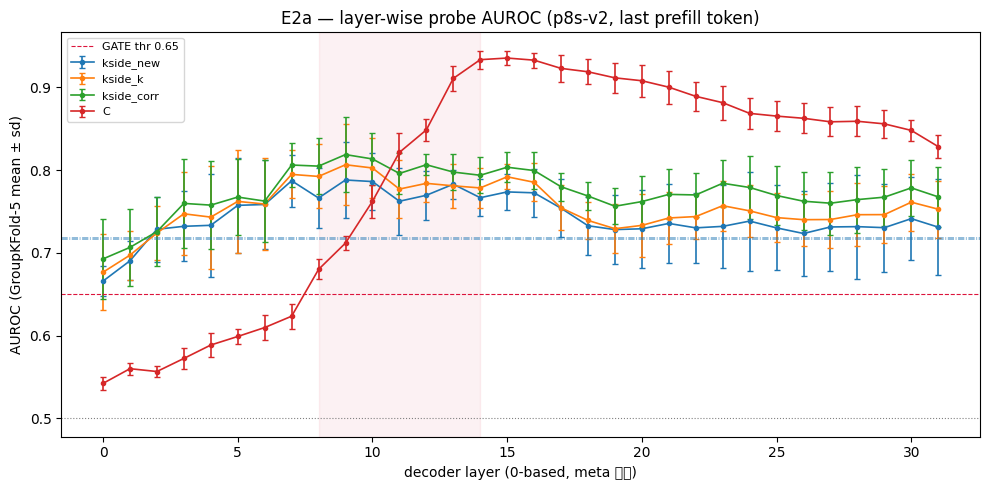

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
for name in list(Y_K) + ["C"]:
    d = res[res.label == name].sort_values("layer")
    ax.errorbar(d.layer, d.auroc_mean, yerr=d.auroc_sd, fmt="-o", ms=3,
                lw=1.2, capsize=2, label=name)
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
ax.axhline(CONFIG["GATE_THR"], color="crimson", lw=0.8, ls="--",
           label=f"GATE thr {CONFIG['GATE_THR']}")
ax.axvspan(CONFIG["GATE_LO"], CONFIG["GATE_HI"], color="crimson", alpha=0.06)
for _, r in ctrl.iterrows():
    ax.axhline(r.tfidf, lw=0.7, ls="-.", alpha=0.5)
ax.set_xlabel("decoder layer (0-based, meta 규약)")
ax.set_ylabel("AUROC (GroupKFold-5 mean ± sd)")
ax.set_title("E2a — layer-wise probe AUROC (p8s-v2, last prefill token)")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(os.path.join(CONFIG["OUT_DIR"], "e2a_auroc.png"), dpi=150)
plt.show()

## 해석 시 주의

- **층 간 미세 차이는 보고하지 않는다.** fold sd가 0.02~0.04이므로 그 안의 차이는 노이즈다.
  "L10이 최적"이 아니라 "L8~11 고원"으로 서술한다.
- **세 라벨의 곡선이 크게 다르면** 결과가 채점 방식에 민감하다는 뜻이다. 어느 라벨을 주 결과로
  쓸지 팀 합의가 필요하다.
- **C± 곡선은 라벨과 무관하므로 어느 조건에서도 같아야 한다.** 달라지면 정렬이나 코드 문제다.
- **층 번호는 0-based**다 (hidden index i == `model.model.layers[i]`). 게이트 구간 L8~14도 0-based 기준으로 읽는다. 기존 보고서의 1-based L8~14는 0-based L7~13이라 한 칸 어긋나므로, 비교 시 반드시 base를 명시한다.
- **프로브는 최종 방법이 아니다.** K 라벨로 학습하므로 training-free가 아니며, PKS(E10a)의
  상한을 보여주는 진단선이다.